# Tuning Neural Networking in Keras

We will use the version of Keras that comes in the Tensorflow package, as it has the most up to date tools.

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from seaborn import heatmap

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, \
accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# New libraries
import tensorflow.keras as keras
from tensorflow.keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense

In [28]:
from sklearn.metrics import confusion_matrix
def eval_classification(model, X, y, name='model', labels=None):
    """Prints a classification report and confusion matrix
    Returns a dataframe with classification metrics.
    """
    preds = np.rint(model.predict(X))

    print(classification_report(y, preds, target_names=labels))

    # Display confusion matrix
    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
    plt.show()

    # Compute confusion matrix for FPR and FNR
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    # Initialize the score dataframe
    score_df = pd.DataFrame(index=[name])
    score_df.loc[name, 'Accuracy'] = accuracy_score(y, preds)
    score_df.loc[name, 'Precision'] = precision_score(y, preds)
    score_df.loc[name, 'Recall'] = recall_score(y, preds)
    score_df.loc[name, 'F1 Score'] = f1_score(y, preds)
    score_df.loc[name, 'False Positive Rate'] = fp / (fp + tn) if (fp + tn) > 0 else 0
    score_df.loc[name, 'False Negative Rate'] = fn / (fn + tp) if (fn + tp) > 0 else 0

    return score_df

def plot_history(history):
  print("""Takes a keras model learning history and plots each metric""")

  metrics = history.history.keys()
  print(metrics)
  for metric in metrics:
      if not 'val' in metric:
        plt.plot(history.history[f'{metric}'], label=f'{metric}')
        if f'val_{metric}' in metrics:
          plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
        plt.legend()
        plt.title(f'{metric}')
        plt.show()


# Classification:

Classification models are similar, except that we need to adjust the final activation of the output layer, the loss function in the compile step, and the metrics we use to judge them.  Remember: MAE, MSE, RMSE, and R2 are regression metrics, accuracy, recall, precision, F1-Score, and confusion matrices are classification metrics.




### Build your model

In [29]:
df_train = pd.read_csv('train.csv')
df_train.head()
# Define X and y and train data
X_train = df_train.drop(columns = 'label')
y_train = df_train['label']

In [30]:
df_val = pd.read_csv('val.csv')
df_val.head()
# Define X and y and train data
X_val = df_val.drop(columns = 'label')
y_val = df_val['label']

In [31]:
# Build your model

n_cols = X_train.shape[1]

# Instentiate the model
class_model1 = Sequential()

# create the first layer with input as the number of features in dataset
class_model1.add(Dense(10, activation = 'relu', input_dim = X_train.shape[1]))

# Create hidden layers
class_model1.add(Dense(10, activation = 'relu'))

# Create output layer
# Since this is a binary classification, the activation function of our final layer needs to be 'sigmoid'.

class_model1.add(Dense(1, activation = 'sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# Compile your model

# Since this is binary classification set loss  = 'binary_crossentropy'
# Set the metrics = ['acc']
class_model1.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['acc'])

In [33]:
# fit your model
history = class_model1.fit(X_train, y_train,
                        validation_data = (X_val, y_val),
                        epochs = 100,
                        verbose=0)

Takes a keras model learning history and plots each metric
dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


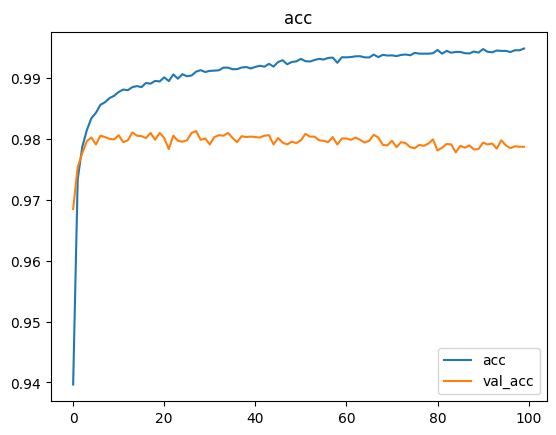

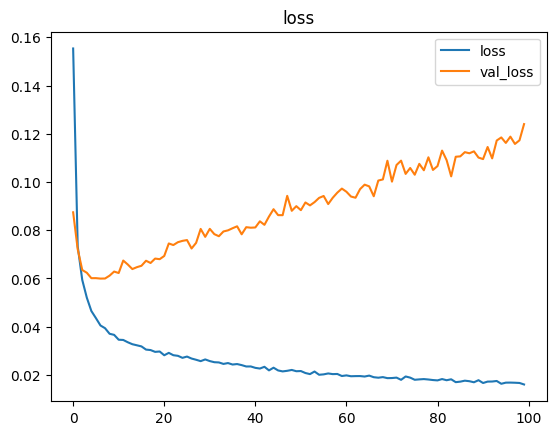

In [34]:
# See how your model is doing
plot_history(history)

## Evaluation



Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       1.00      1.00      1.00     25308
   Phishing Email       1.00      1.00      1.00     27484

         accuracy                           1.00     52792
        macro avg       1.00      1.00      1.00     52792
     weighted avg       1.00      1.00      1.00     52792



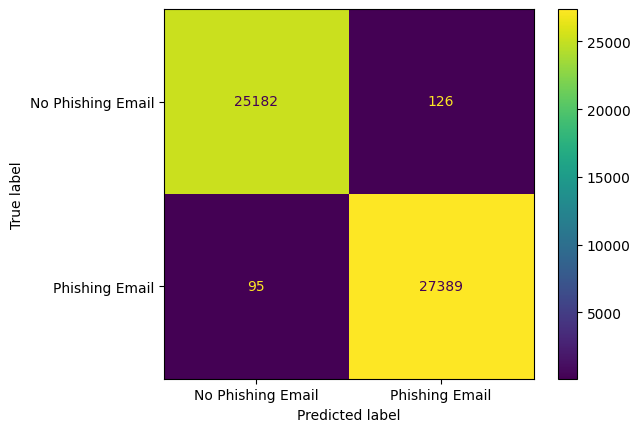

Val Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.97      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



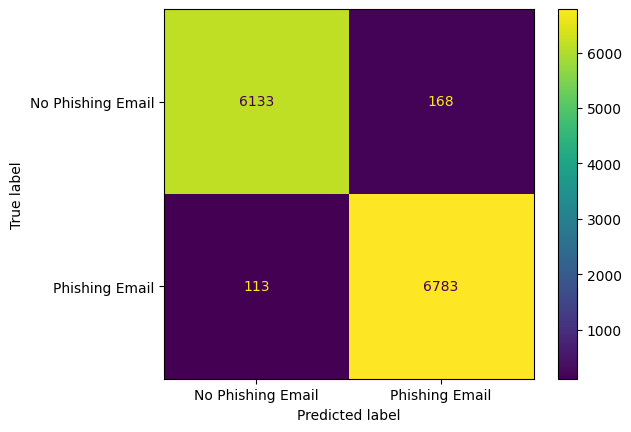

,Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate
class_model1 train,0.995814,0.995421,0.996543,0.995982,0.004979,0.003457
class_model1 test,0.978707,0.975831,0.983614,0.979707,0.026662,0.016386


In [35]:
# Make predicitons and evaluate your model
# Define labels for the confusion matrix
labels = ['No Phishing Email', 'Phishing Email']

# Evaluate training set
print('Training Evaluation:\n')
train_scores = eval_classification(class_model1,
                             X_train, y_train,
                             name='class_model1 train',
                             labels=labels)
print('Val Evaluation:\n')
# Confusion Matrix
test_scores = (eval_classification(class_model1,
                                           X_val, y_val,
                                           name='class_model1 test',
                                           labels=labels))

scores = pd.concat([train_scores, test_scores])
scores

# 👉 Tuning an underfit model:
##Increase model complexity:
1. add layers  
2. add nodes
3. reduce other regularization

# 👉 Tuning an overfit model:
## Reduce model complexity:
1. Reduce layers or nodes
2. Add dropout layers
3. Implement early stopping callback
3. Add L1 or L2 regularization


# 🔧 Your Turn: Tune This Model!

* Choose one or more regularization techniques to improve this model.

* Make one change at a time.  Make a new cell for each change to keep a record of what you've tried.

##Ask yourselves:  Should you increase or decrease model complexity?

# 🥷🏽 Hint:
Feel free to copy/paste the modeling code from above and then make changes.  

Remember to change the model name!